In [72]:
#1.1 Load the dataset (and environment)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns


In [39]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [40]:
# 1.2 Data cleaning
# Check for totally missing values (none found)
df.isnull().values.any(), df.isna().values.any()

(np.False_, np.False_)

In [41]:
# Impute placeholder (zero) values
ls = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
              'BMI', 'DiabetesPedigreeFunction', 'Age']
for label in ls:
    # Calculate mean val (do not include 0's when calculating)
    mean_val = df.loc[df[label] != 0, label].mean()
    # Update all 0's with mean_val
    df.loc[df[label] == 0, label] = mean_val

df.head()


C:\Users\zecerman\AppData\Local\Temp\ipykernel_15868\4275525496.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '121.6867627785059' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[label] == 0, label] = mean_val
C:\Users\zecerman\AppData\Local\Temp\ipykernel_15868\4275525496.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '72.40518417462484' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[label] == 0, label] = mean_val
C:\Users\zecerman\AppData\Local\Temp\ipykernel_15868\4275525496.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '29.153419593345657' has dtype incompatible with int64, please explicitly cast to a compatible dtype first

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33.0,1


In [42]:
# 1.3 Train test split
X_features = list(df.columns)
X_features.remove('Outcome')
X = df[X_features].values
y = df['Outcome'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
# 1.4 Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
# 2.1 Create and fit the tree, make predictions
tree_model = DecisionTreeClassifier(criterion='entropy', ccp_alpha=0.01, random_state=42)
tree_model.fit(X_train, y_train)

tree_y_pred = tree_model.predict(X_test)
tree_y_pred

array([1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0])

In [60]:
# 2.2 Evaluate the model performance
def evaluate(y_test, y_pred, title):
    # Create a "Performance DataFrame"
    pdf = pd.DataFrame({'actual' : y_test, 'pred' : y_pred })
    # Calculate performance metrics 
    TP = len(pdf.where((pdf['actual'] == 1) & (pdf['pred'] == 1)).dropna())
    TN = len(pdf.where((pdf['actual'] == 0) & (pdf['pred'] == 0)).dropna())
    FP = len(pdf.where((pdf['actual'] == 0) & (pdf['pred'] == 1)).dropna())
    FN = len(pdf.where((pdf['actual'] == 1) & (pdf['pred'] == 0)).dropna())

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    F1_score = 2 * (precision * recall) / (precision + recall)

    print(f"{title} Model Performance:")
    print(f"--------------------------------")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {F1_score:.4f}")

evaluate(y_test, tree_y_pred, 'Decision Tree')

Decision Tree Model Performance:
--------------------------------
Accuracy: 0.7468
Precision: 0.6176
Recall: 0.7636
F1 Score: 0.6829


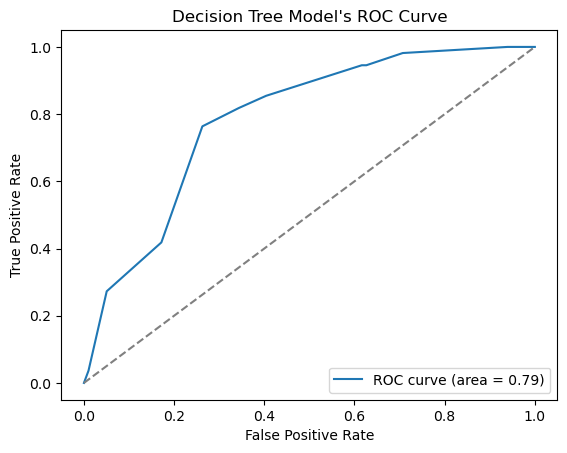

In [88]:
# Visualize performance w/ ROC curve

# Get prob
y_proba = tree_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve INCLUDING AUC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree Model\'s ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [89]:
# 2.3 Compare model performance with multiple linear regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

log_y_pred = log_model.predict(X_test) 
# Calculate performance metrics 
evaluate(y_test, log_y_pred, 'Regression')

Regression Model Performance:
--------------------------------
Accuracy: 0.7532
Precision: 0.6667
Recall: 0.6182
F1 Score: 0.6415


In [90]:
# Recall performance of tree model:
evaluate(y_test, tree_y_pred, 'Decision Tree')

Decision Tree Model Performance:
--------------------------------
Accuracy: 0.7468
Precision: 0.6176
Recall: 0.7636
F1 Score: 0.6829


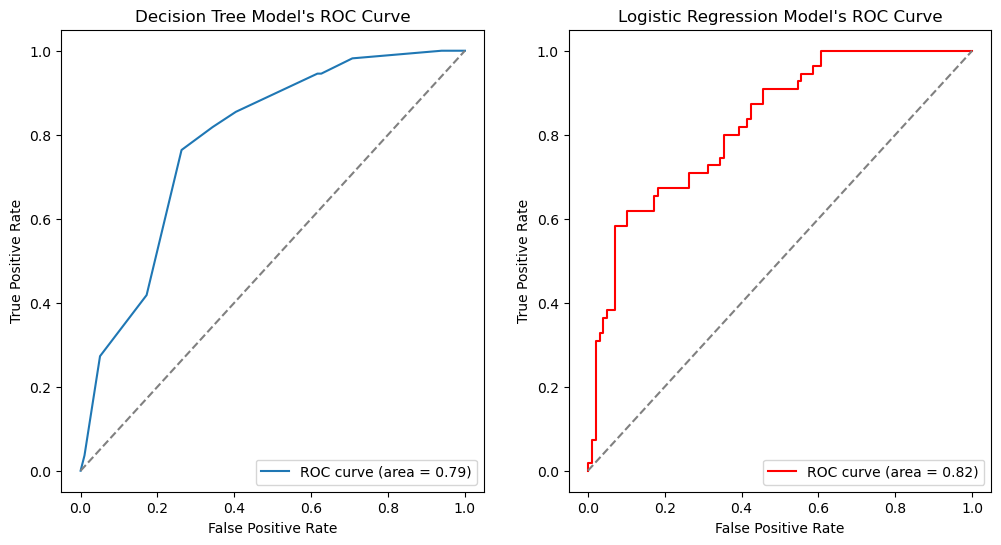

In [ ]:
# Visualize performance of both models w/ ROC curve INCLUDING AUC

# Get prob
y_proba = tree_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree Model\'s ROC Curve')
plt.legend(loc='lower right')

# Get prob for log model
y_proba = log_model.predict_proba(X_test)[:, 1]

# Compute ROC curve for log model
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.subplot(1,2,2)
plt.plot(fpr, tpr, color='red', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression Model\'s ROC Curve')
plt.legend(loc='lower right')